# Home Work 5

# task 1 Imagenet

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

In [ ]:
folder = '/content/drive/MyDrive/Machine learning 2/Week 5/data/imagenet'
imagenet_root = folder
os.listdir(folder)

['ILSVRC2012_devkit_t12.tar',
 'ILSVRC2012_img_val.tar',
 'ILSVRC2012_devkit_t12.tar.gz',
 'meta.bin',
 'val',
 'ILSVRC2012_devkit_t12']

In [ ]:
!curl -L "https://image-net.org/data/ILSVRC/2012/ILSVRC2012_devkit_t12.tar.gz" \
-o ../data/imagenet/ILSVRC2012_devkit_t12.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2507k  100 2507k    0     0  6962k      0 --:--:-- --:--:-- --:--:-- 6966k


In [ ]:
import os
import urllib.request

os.makedirs("../data/imagenet", exist_ok=True)

url = "https://image-net.org/data/ILSVRC/2012/ILSVRC2012_devkit_t12.tar.gz"
output_path = "../data/imagenet/ILSVRC2012_devkit_t12.tar.gz"

urllib.request.urlretrieve(url, output_path)

('../data/imagenet/ILSVRC2012_devkit_t12.tar.gz',
 <http.client.HTTPMessage at 0x7dba93168f20>)

In [ ]:
import os


expected_files = [
    "ILSVRC2012_devkit_t12.tar.gz",
    "ILSVRC2012_img_val.tar",
]

for fname in expected_files:
    path = os.path.join(folder, fname)
    print(fname, "FOUND" if os.path.exists(path) else "MISSING")

ILSVRC2012_devkit_t12.tar.gz FOUND
ILSVRC2012_img_val.tar FOUND


# Extracting files from archive

In [ ]:
import tarfile

tar_path = "/content/drive/MyDrive/Machine learning 2/Week 5/data/imagenet/ILSVRC2012_devkit_t12.tar.gz"
extract_path = "/content/drive/MyDrive/Machine learning 2/Week 5/data/imagenet/"

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

/tmp/ipykernel_1644/3362098740.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


In [ ]:
import os
import shutil
from scipy.io import loadmat

devkit_path = os.path.join(imagenet_root, "ILSVRC2012_devkit_t12/data/meta.mat")
val_gt_path = os.path.join(imagenet_root, "ILSVRC2012_devkit_t12/data/ILSVRC2012_validation_ground_truth.txt")
val_images_path = os.path.join(imagenet_root, "val")

# Load metadata
meta = loadmat(devkit_path, squeeze_me=True)['synsets']
id_to_wnid = {m[0]: m[1] for m in meta if m[0] <= 1000}

# Load ground truth labels
with open(val_gt_path) as f:
    labels = [int(x.strip()) for x in f.readlines()]

# Create class folders + move images
images = sorted(os.listdir(val_images_path))

for img, label in zip(images, labels):
    wnid = id_to_wnid[label]
    class_dir = os.path.join(val_images_path, wnid)
    os.makedirs(class_dir, exist_ok=True)
    shutil.move(os.path.join(val_images_path, img),
                os.path.join(class_dir, img))

In [ ]:
from torchvision.datasets import ImageNet

imagenet_val = ImageNet(root=imagenet_root, split="val")
print(f"Validation set size: {len(imagenet_val)}")

Validation set size: 3476


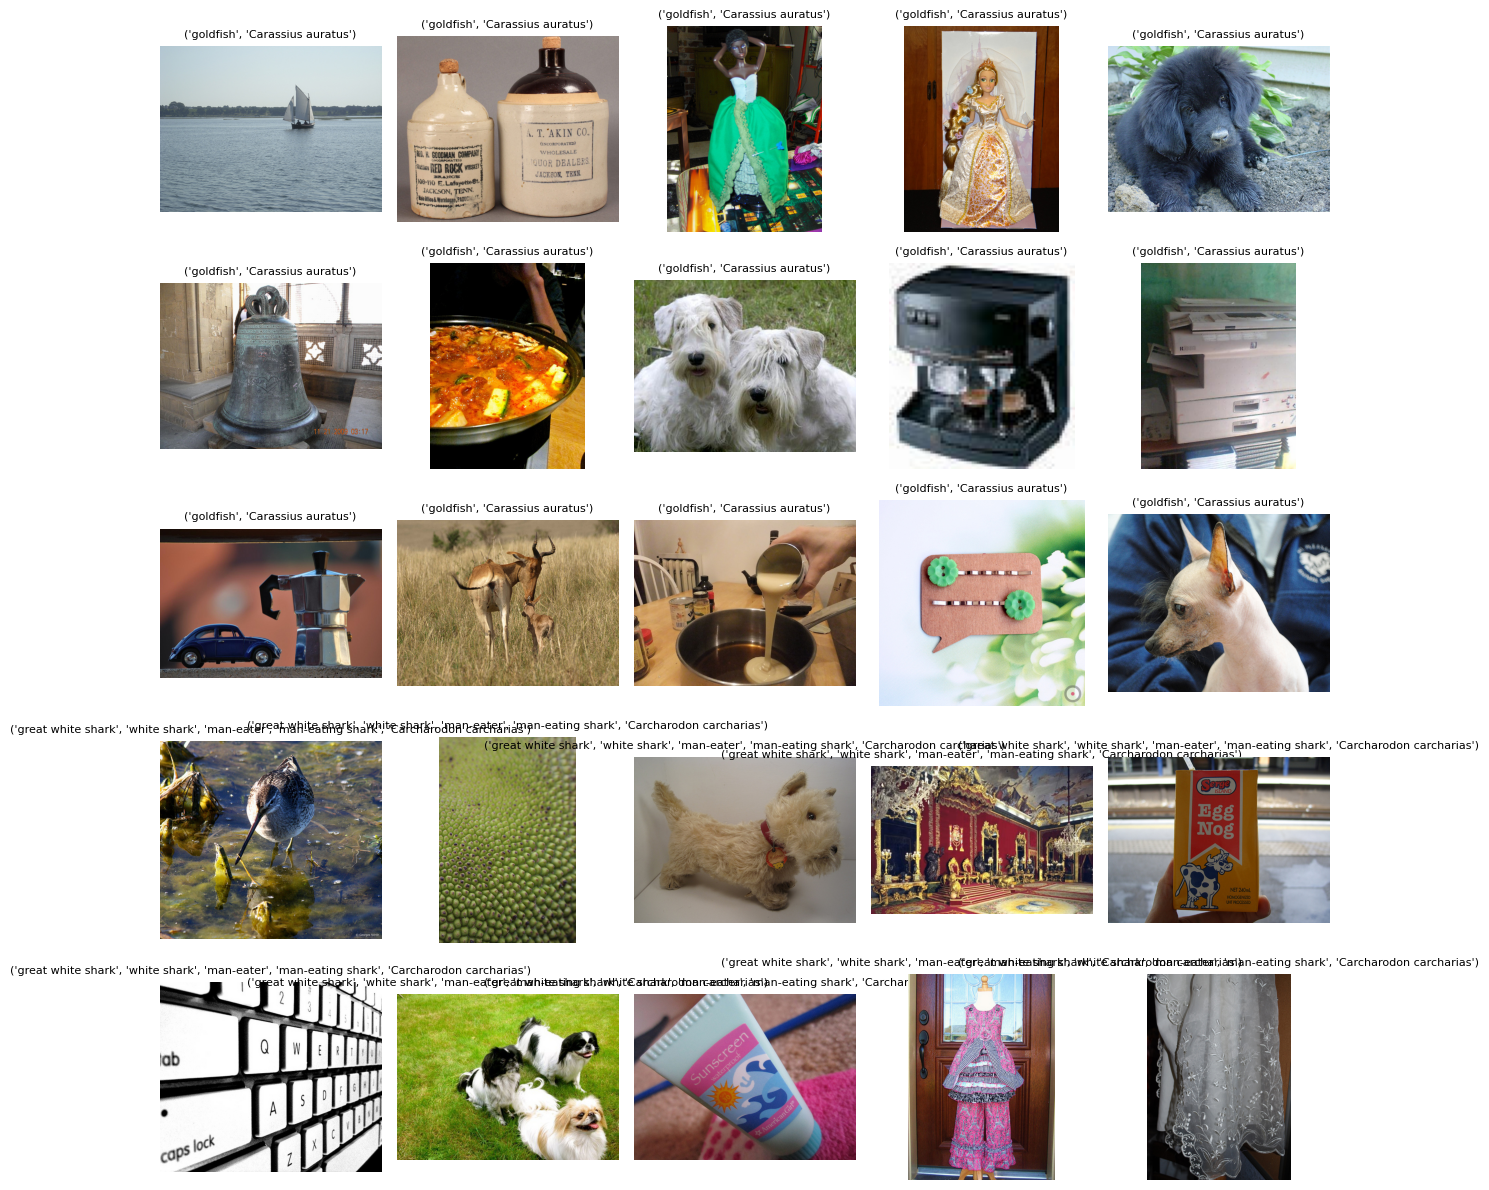

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for i, ax in enumerate(axes.flatten()):
    img, label = imagenet_val[i]

    ax.imshow(np.array(img))
    ax.set_title(imagenet_val.classes[label], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

#Group torchvision models into families

In [ ]:
import torchvision.models as models
import pandas as pd
import re

# -----------------------------
# 1. Get all available model names
# -----------------------------
all_models = sorted([
    name for name in dir(models)
    if callable(getattr(models, name))
    and not name.startswith("_")
])

# -----------------------------
# 2. Define family extraction rule
# -----------------------------
def get_family(name):
    name = name.lower()

    # preserve versioned families
    if name.startswith("resnet"):
        return "resnet"
    if name.startswith("vgg"):
        return "vgg"
    if name.startswith("alexnet"):
        return "alexnet"
    if name.startswith("densenet"):
        return "densenet"
    if name.startswith("mobilenet"):
        return "mobilenet"
    if name.startswith("efficientnet"):
        return "efficientnet"
    if name.startswith("convnext"):
        return "convnext"
    if name.startswith("squeezenet"):
        return "squeezenet"
    if name.startswith("googlenet"):
        return "googlenet"
    if name.startswith("inception"):
        return "inception"
    if name.startswith("shufflenet"):
        return "shufflenet"
    if name.startswith("regnet"):
        return "regnet"
    if name.startswith("mnasnet"):
        return "mnasnet"
    if name.startswith("vit"):
        return "vision_transformer"
    if "resnext" in name:
        return "resnext"
    if "wide_resnet" in name:
        return "wide_resnet"

    return "other"

# -----------------------------
# 3. Group models
# -----------------------------
groups = {}

for m in all_models:
    family = get_family(m)
    groups.setdefault(family, []).append(m)

# -----------------------------
# 4. Build DataFrame
# -----------------------------
data = []

for family, variants in groups.items():
    data.append({
        "family": family,
        "num_variants": len(variants),
        "variants": sorted(variants)
    })

df = pd.DataFrame(data)

# Sort: size desc, then family name
df = df.sort_values(
    by=["num_variants", "family"],
    ascending=[False, True]
)

# -----------------------------
# 5. Summary stats
# -----------------------------
total_models = len(all_models)
total_families = len(groups)

print(f"Total models: {total_models}")
print(f"Total families: {total_families}")

# -----------------------------
# 6. Display result
# -----------------------------
display(df)

Total models: 186
Total families: 17


,family,num_variants,variants
9,regnet,31,"[RegNet, RegNet_X_16GF_Weights, RegNet_X_1_6GF..."
7,other,24,"[MaxVit, MaxVit_T_Weights, SwinTransformer, Sw..."
3,efficientnet,23,"[EfficientNet, EfficientNet_B0_Weights, Effici..."
14,vgg,17,"[VGG, VGG11_BN_Weights, VGG11_Weights, VGG13_B..."
11,resnet,11,"[ResNet, ResNet101_Weights, ResNet152_Weights,..."
15,vision_transformer,10,"[ViT_B_16_Weights, ViT_B_32_Weights, ViT_H_14_..."
1,convnext,9,"[ConvNeXt, ConvNeXt_Base_Weights, ConvNeXt_Lar..."
2,densenet,9,"[DenseNet, DenseNet121_Weights, DenseNet161_We..."
6,mnasnet,9,"[MNASNet, MNASNet0_5_Weights, MNASNet0_75_Weig..."
12,shufflenet,9,"[ShuffleNetV2, ShuffleNet_V2_X0_5_Weights, Shu..."


#image classification models

In [ ]:
import torch
import torch.nn as nn
import pandas as pd

from torchvision import models

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Shared model registry
# -----------------------------
registry = {
    "alexnet": lambda: models.alexnet(weights=models.AlexNet_Weights.DEFAULT),
    "vgg16": lambda: models.vgg16(weights=models.VGG16_Weights.DEFAULT),
    "resnet50": lambda: models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
    "efficientnet_b0": lambda: models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT),
    "efficientnet_b4": lambda: models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT),
    "convnext_tiny": lambda: models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT),
    "densenet121": lambda: models.densenet121(weights=models.DenseNet121_Weights.DEFAULT),
    "mobilenet_v3_large": lambda: models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT),
}

# -----------------------------
# Helpers
# -----------------------------
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def extract_arch_info(model):
    activations = set()
    pools = set()
    norms = set()

    has_conv = False
    has_linear = False
    has_attention = False

    for m in model.modules():
        name = m.__class__.__name__

        # activations
        if isinstance(m, (nn.ReLU, nn.ReLU6, nn.GELU, nn.SiLU, nn.Hardswish)):
            activations.add(name)

        # pooling
        if isinstance(m, (nn.MaxPool2d, nn.AvgPool2d, nn.AdaptiveAvgPool2d)):
            pools.add(name)

        # normalization
        if isinstance(m, (nn.BatchNorm2d, nn.LayerNorm, nn.GroupNorm)):
            norms.add(name)

        # layer types
        if isinstance(m, nn.Conv2d):
            has_conv = True
        if isinstance(m, nn.Linear):
            has_linear = True

        # attention heuristic (ConvNeXt / transformer-style blocks)
        if "Attention" in name or "MultiheadAttention" in name:
            has_attention = True

    return {
        "activations": ", ".join(sorted(activations)) if activations else "None",
        "pooling": ", ".join(sorted(pools)) if pools else "None",
        "normalization": ", ".join(sorted(norms)) if norms else "None",
        "has_conv": has_conv,
        "has_linear": has_linear,
        "has_attention": has_attention,
    }

# -----------------------------
# Build analysis
# -----------------------------
results = []

for name, builder in registry.items():
    print(f"Loading {name}...")

    model = builder().to(device)
    model.eval()

    total_params, trainable_params = count_params(model)
    arch_info = extract_arch_info(model)

    results.append({
        "model": name,
        "total_params": total_params,
        "trainable_params": trainable_params,
        **arch_info
    })

# -----------------------------
# DataFrame
# -----------------------------
df = pd.DataFrame(results)

# sort by size
df = df.sort_values("total_params")

# transposed view
df_t = df.set_index("model").T

display(df_t)

Loading alexnet...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 85.5MB/s]


Loading vgg16...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 160MB/s]


Loading resnet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


...

Loading densenet121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 162MB/s]


Loading mobilenet_v3_large...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 149MB/s]


model,efficientnet_b0,mobilenet_v3_large,densenet121,efficientnet_b4,resnet50,convnext_tiny,alexnet,vgg16
total_params,5288548,5483032,7978856,19341616,25557032,28589128,61100840,138357544
trainable_params,5288548,5483032,7978856,19341616,25557032,28589128,61100840,138357544
activations,SiLU,"Hardswish, ReLU",ReLU,SiLU,ReLU,GELU,ReLU,ReLU
pooling,AdaptiveAvgPool2d,AdaptiveAvgPool2d,"AvgPool2d, MaxPool2d",AdaptiveAvgPool2d,"AdaptiveAvgPool2d, MaxPool2d",AdaptiveAvgPool2d,"AdaptiveAvgPool2d, MaxPool2d","AdaptiveAvgPool2d, MaxPool2d"
normalization,BatchNorm2d,BatchNorm2d,BatchNorm2d,BatchNorm2d,BatchNorm2d,"LayerNorm, LayerNorm2d",None,None
has_conv,True,True,True,True,True,True,True,True
has_linear,True,True,True,True,True,True,True,True
has_attention,False,False,False,False,False,False,False,False


#ImageNet Multi-Model Evaluation Pipeline

In [ ]:
import torch
import pandas as pd
from torchvision import models
from torchvision.datasets import ImageNet
from torch.utils.data import DataLoader
from tqdm import tqdm

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Model registry with weights
# -----------------------------
registry = {
    "alexnet": models.alexnet,
    "vgg16": models.vgg16,
    "resnet50": models.resnet50,
    "efficientnet_b0": models.efficientnet_b0,
    "efficientnet_b4": models.efficientnet_b4,
    "convnext_tiny": models.convnext_tiny,
    "densenet121": models.densenet121,
    "mobilenet_v3_large": models.mobilenet_v3_large,
}

weight_map = {
    "alexnet": models.AlexNet_Weights.DEFAULT,
    "vgg16": models.VGG16_Weights.DEFAULT,
    "resnet50": models.ResNet50_Weights.DEFAULT,
    "efficientnet_b0": models.EfficientNet_B0_Weights.DEFAULT,
    "efficientnet_b4": models.EfficientNet_B4_Weights.DEFAULT,
    "convnext_tiny": models.ConvNeXt_Tiny_Weights.DEFAULT,
    "densenet121": models.DenseNet121_Weights.DEFAULT,
    "mobilenet_v3_large": models.MobileNet_V3_Large_Weights.DEFAULT,
}

# -----------------------------
# Load dataset (validation)
# -----------------------------

results = []

# -----------------------------
# Evaluation loop
# -----------------------------
for model_name in registry:

    print(f"\nEvaluating {model_name}...")

    weights = weight_map[model_name]
    preprocess = weights.transforms()

    val_dataset = ImageNet(
        root=imagenet_root,
        split="val",
        transform=preprocess
    )

    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

    model = registry[model_name](weights=weights).to(device)
    model.eval()

    correct1 = 0
    correct5 = 0
    total = 0

    with torch.no_grad():
        for images, targets in tqdm(val_loader):
            images, targets = images.to(device), targets.to(device)

            outputs = model(images)

            # Top-1
            _, pred1 = outputs.topk(1, dim=1)
            correct1 += (pred1.squeeze() == targets).sum().item()

            # Top-5
            _, pred5 = outputs.topk(5, dim=1)
            correct5 += sum([targets[i] in pred5[i] for i in range(targets.size(0))])

            total += targets.size(0)

    top1 = correct1 / total * 100
    top5 = correct5 / total * 100

    results.append({
        "model": model_name,
        "top1_accuracy": top1,
        "top5_accuracy": top5,
        "num_classes": 1000,
        "weights": str(weights)
    })

# -----------------------------
# Results table
# -----------------------------
df = pd.DataFrame(results)

df = df.sort_values(
    by=["top1_accuracy", "top5_accuracy"],
    ascending=False
)

display(df)


Evaluating alexnet...


100%|██████████| 55/55 [09:50<00:00, 10.74s/it]



Evaluating vgg16...


100%|██████████| 55/55 [00:38<00:00,  1.42it/s]



Evaluating resnet50...


...


Evaluating densenet121...


100%|██████████| 55/55 [00:36<00:00,  1.50it/s]



Evaluating mobilenet_v3_large...


100%|██████████| 55/55 [00:35<00:00,  1.57it/s]


,model,top1_accuracy,top5_accuracy,num_classes,weights
0,alexnet,0.057537,0.489068,1000,AlexNet_Weights.IMAGENET1K_V1
6,densenet121,0.057537,0.258918,1000,DenseNet121_Weights.IMAGENET1K_V1
4,efficientnet_b4,0.057537,0.201381,1000,EfficientNet_B4_Weights.IMAGENET1K_V1
5,convnext_tiny,0.028769,0.402762,1000,ConvNeXt_Tiny_Weights.IMAGENET1K_V1
3,efficientnet_b0,0.028769,0.373993,1000,EfficientNet_B0_Weights.IMAGENET1K_V1
7,mobilenet_v3_large,0.028769,0.345224,1000,MobileNet_V3_Large_Weights.IMAGENET1K_V2
1,vgg16,0.028769,0.316456,1000,VGG16_Weights.IMAGENET1K_V1
2,resnet50,0.028769,0.230150,1000,ResNet50_Weights.IMAGENET1K_V2


#Multi-Model Prediction Visualization (ImageNet)

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from torchvision import models
from torchvision.datasets import ImageNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_names = [
    "alexnet",
    "vgg16",
    "resnet50",
    "efficientnet_b0",
    "efficientnet_b4",
    "convnext_tiny",
    "densenet121",
    "mobilenet_v3_large"
]

registry = {
    "alexnet": models.alexnet,
    "vgg16": models.vgg16,
    "resnet50": models.resnet50,
    "efficientnet_b0": models.efficientnet_b0,
    "efficientnet_b4": models.efficientnet_b4,
    "convnext_tiny": models.convnext_tiny,
    "densenet121": models.densenet121,
    "mobilenet_v3_large": models.mobilenet_v3_large,
}

weight_map = {
    "alexnet": models.AlexNet_Weights.DEFAULT,
    "vgg16": models.VGG16_Weights.DEFAULT,
    "resnet50": models.ResNet50_Weights.DEFAULT,
    "efficientnet_b0": models.EfficientNet_B0_Weights.DEFAULT,
    "efficientnet_b4": models.EfficientNet_B4_Weights.DEFAULT,
    "convnext_tiny": models.ConvNeXt_Tiny_Weights.DEFAULT,
    "densenet121": models.DenseNet121_Weights.DEFAULT,
    "mobilenet_v3_large": models.MobileNet_V3_Large_Weights.DEFAULT,
}

In [ ]:


val_raw = ImageNet(
    root=imagenet_root,
    split="val",
    transform=None
)

In [ ]:
sample_indices = [0, 10, 25]  # change as needed

In [ ]:
def predict(model, preprocess, image):
    model.eval()

    x = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0]

    top5 = torch.topk(probs, 5)

    return top5.indices.cpu().numpy(), top5.values.cpu().numpy()

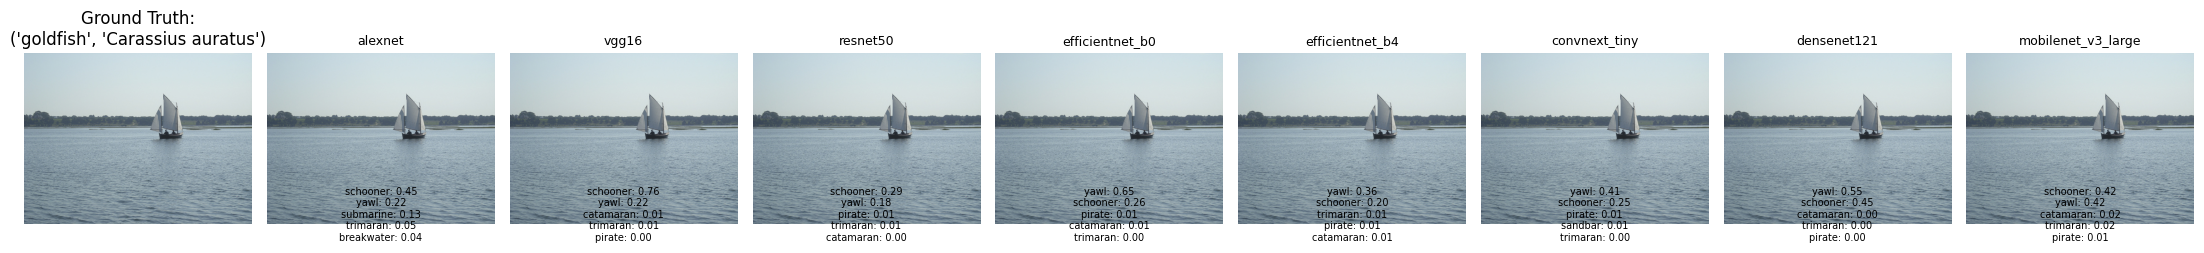

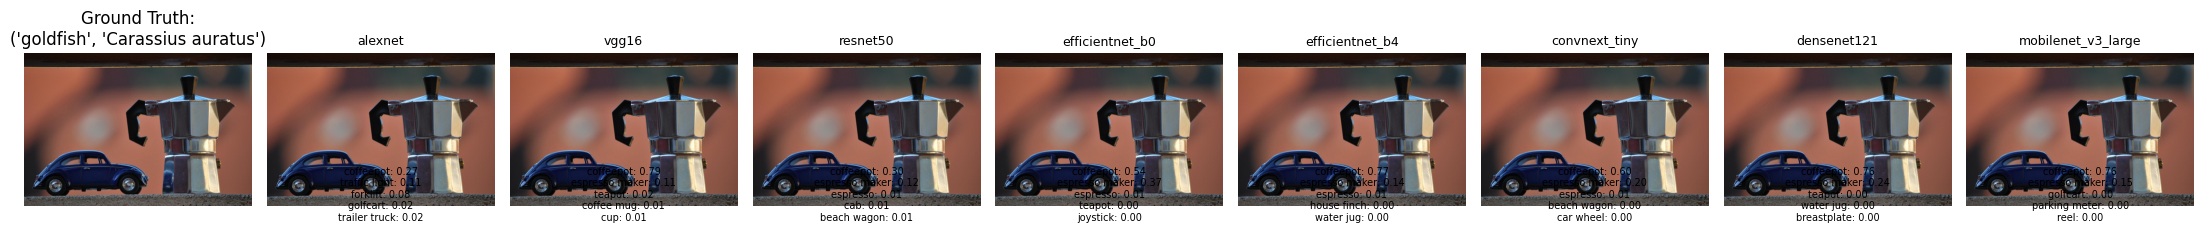

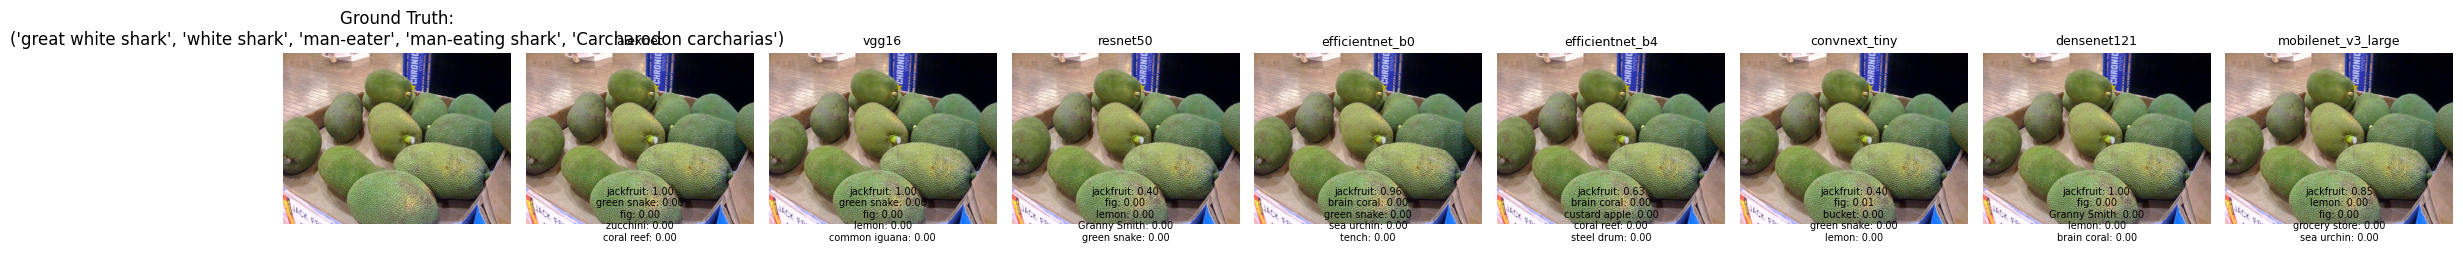

In [ ]:
for idx in sample_indices:

    image, label = val_raw[idx]
    true_class = val_raw.classes[label]

    fig, axes = plt.subplots(
        1, len(model_names) + 1,
        figsize=(22, 5)
    )

    # show original image
    axes[0].imshow(image)
    axes[0].set_title(f"Ground Truth:\n{true_class}")
    axes[0].axis("off")

    for i, name in enumerate(model_names):

        weights = weight_map[name]
        preprocess = weights.transforms()

        model = registry[name](weights=weights).to(device)

        top5_idx, top5_prob = predict(model, preprocess, image)

        class_names = weights.meta["categories"]

        pred_text = "\n".join([
            f"{class_names[i]}: {p:.2f}"
            for i, p in zip(top5_idx, top5_prob)
        ])

        axes[i + 1].imshow(image)
        axes[i + 1].set_title(name, fontsize=9)
        axes[i + 1].axis("off")

        axes[i + 1].text(
            0.5, -0.1,
            pred_text,
            fontsize=7,
            ha="center",
            transform=axes[i + 1].transAxes
        )

    plt.tight_layout()
    plt.show()

In [35]:
import datetime

In [43]:
print(datetime.datetime.now())

2026-04-26 04:56:05.879065
